----

### **Launch the FASTAPI: Run** `uvicorn api_app:app --reload` to start the **FASTAPI** server.

### **api_app.py**
```Python
from fastapi import FastAPI, HTTPException, Depends
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field
from datetime import date, datetime
from typing import Optional
from crewai import Crew, LLM
from trip_agents import TripAgents
from trip_tasks import TripTasks
import os
from dotenv import load_dotenv
from functools import lru_cache

# Load environment variables
load_dotenv()

app = FastAPI(
    title="VacAIgent API",
    description="AI-powered travel planning API using CrewAI",
    version="1.0.0"
)

# Configure CORS
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],  # In production, replace with specific origins
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

class TripRequest(BaseModel):
    origin: str = Field(..., 
        example="Bangalore, India",
        description="Your current location")
    destination: str = Field(..., 
        example="Krabi, Thailand",
        description="Destination city and country")
    start_date: date = Field(..., 
        example="2025-10-20",
        description="Start date of your trip")
    end_date: date = Field(..., 
        example="2025-10-22",
        description="End date of your trip")
    interests: str = Field(..., 
        example="2 adults who love swimming, dancing, hiking, shopping, local food, water sports adventures and rock climbing",
        description="Your interests and trip details")

class TripResponse(BaseModel):
    status: str
    message: str
    itinerary: Optional[str] = None
    error: Optional[str] = None

class Settings:
    def __init__(self):
        self.GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
        self.SERPER_API_KEY = os.getenv("SERPER_API_KEY")
        self.BROWSERLESS_API_KEY = os.getenv("BROWSERLESS_API_KEY")

@lru_cache()
def get_settings():
    return Settings()

def validate_api_keys(settings: Settings = Depends(get_settings)):
    required_keys = {
        'GEMINI_API_KEY': settings.GEMINI_API_KEY,
        'SERPER_API_KEY': settings.SERPER_API_KEY,
        'BROWSERLESS_API_KEY': settings.BROWSERLESS_API_KEY
    }
    
    missing_keys = [key for key, value in required_keys.items() if not value]
    if missing_keys:
        raise HTTPException(
            status_code=500,
            detail=f"Missing required API keys: {', '.join(missing_keys)}"
        )
    return settings

class TripCrew:
    def __init__(self, origin, destination, date_range, interests):
        self.destination = destination
        self.origin = origin
        self.interests = interests
        self.date_range = date_range
        self.llm = LLM(model="gemini/gemini-2.0-flash")

    def run(self):
        try:
            agents = TripAgents(llm=self.llm)
            tasks = TripTasks()

            city_selector_agent = agents.city_selection_agent()
            local_expert_agent = agents.local_expert()
            travel_concierge_agent = agents.travel_concierge()

            identify_task = tasks.identify_task(
                city_selector_agent,
                self.origin,
                self.destination,
                self.interests,
                self.date_range
            )

            gather_task = tasks.gather_task(
                local_expert_agent,
                self.origin,
                self.interests,
                self.date_range
            )

            plan_task = tasks.plan_task(
                travel_concierge_agent,
                self.origin,
                self.interests,
                self.date_range
            )

            crew = Crew(
                agents=[
                    city_selector_agent, local_expert_agent, travel_concierge_agent
                ],
                tasks=[identify_task, gather_task, plan_task],
                verbose=True
            )

            result = crew.kickoff()
            # Convert CrewOutput to string and ensure it's properly formatted
            return result.raw if hasattr(result, 'raw') else str(result)
        except Exception as e:
            raise HTTPException(
                status_code=500,
                detail=str(e)
            )

@app.get("/")
async def root():
    return {
        "message": "Welcome to VacAIgent API",
        "docs_url": "/docs",
        "redoc_url": "/redoc"
    }

@app.post("/api/v1/plan-trip", response_model=TripResponse)
async def plan_trip(
    trip_request: TripRequest,
    settings: Settings = Depends(validate_api_keys)
):
    # Validate dates
    if trip_request.end_date <= trip_request.start_date:
        raise HTTPException(
            status_code=400,
            detail="End date must be after start date"
        )

    # Format date range
    date_range = f"{trip_request.start_date} to {trip_request.end_date}"

    try:
        trip_crew = TripCrew(
            trip_request.origin,
            trip_request.destination,
            date_range,
            trip_request.interests
        )
        
        itinerary = trip_crew.run()
        
        # Ensure itinerary is a string
        if not isinstance(itinerary, str):
            itinerary = str(itinerary)
            
        return TripResponse(
            status="success",
            message="Trip plan generated successfully",
            itinerary=itinerary
        )
    
    except Exception as e:
        return TripResponse(
            status="error",
            message="Failed to generate trip plan",
            error=str(e)
        )

@app.get("/api/v1/health")
async def health_check():
    return {
        "status": "healthy",
        "timestamp": datetime.now().isoformat()
    }

if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="0.0.0.0", port=8000)
```

---

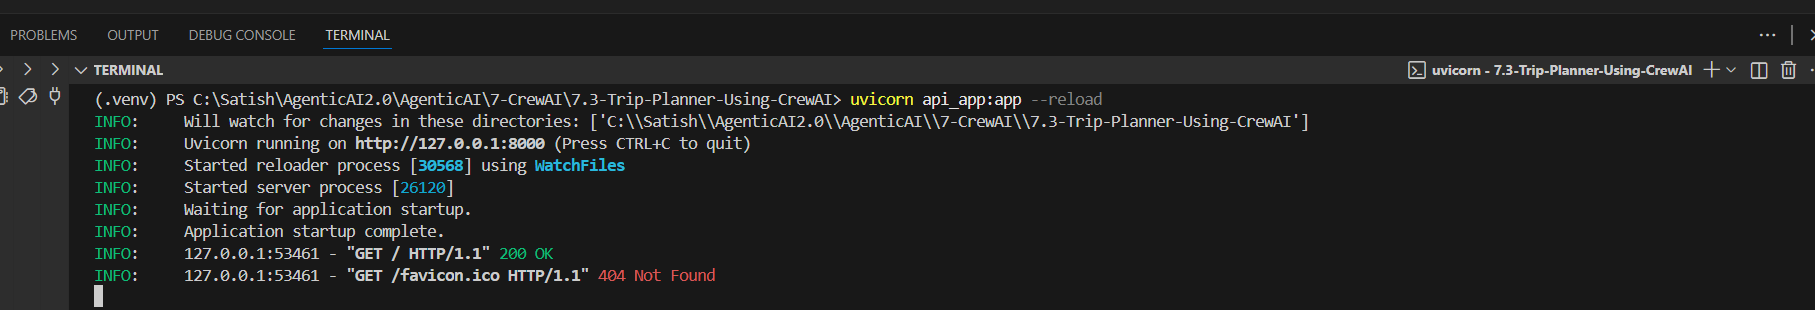 <br><br> 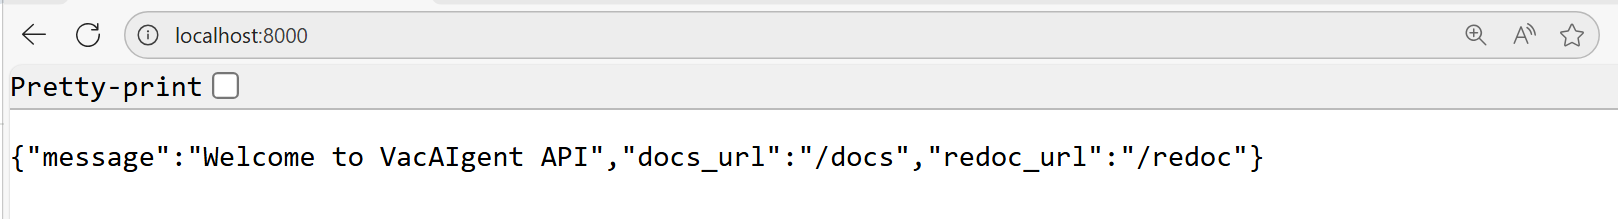 <br><br> 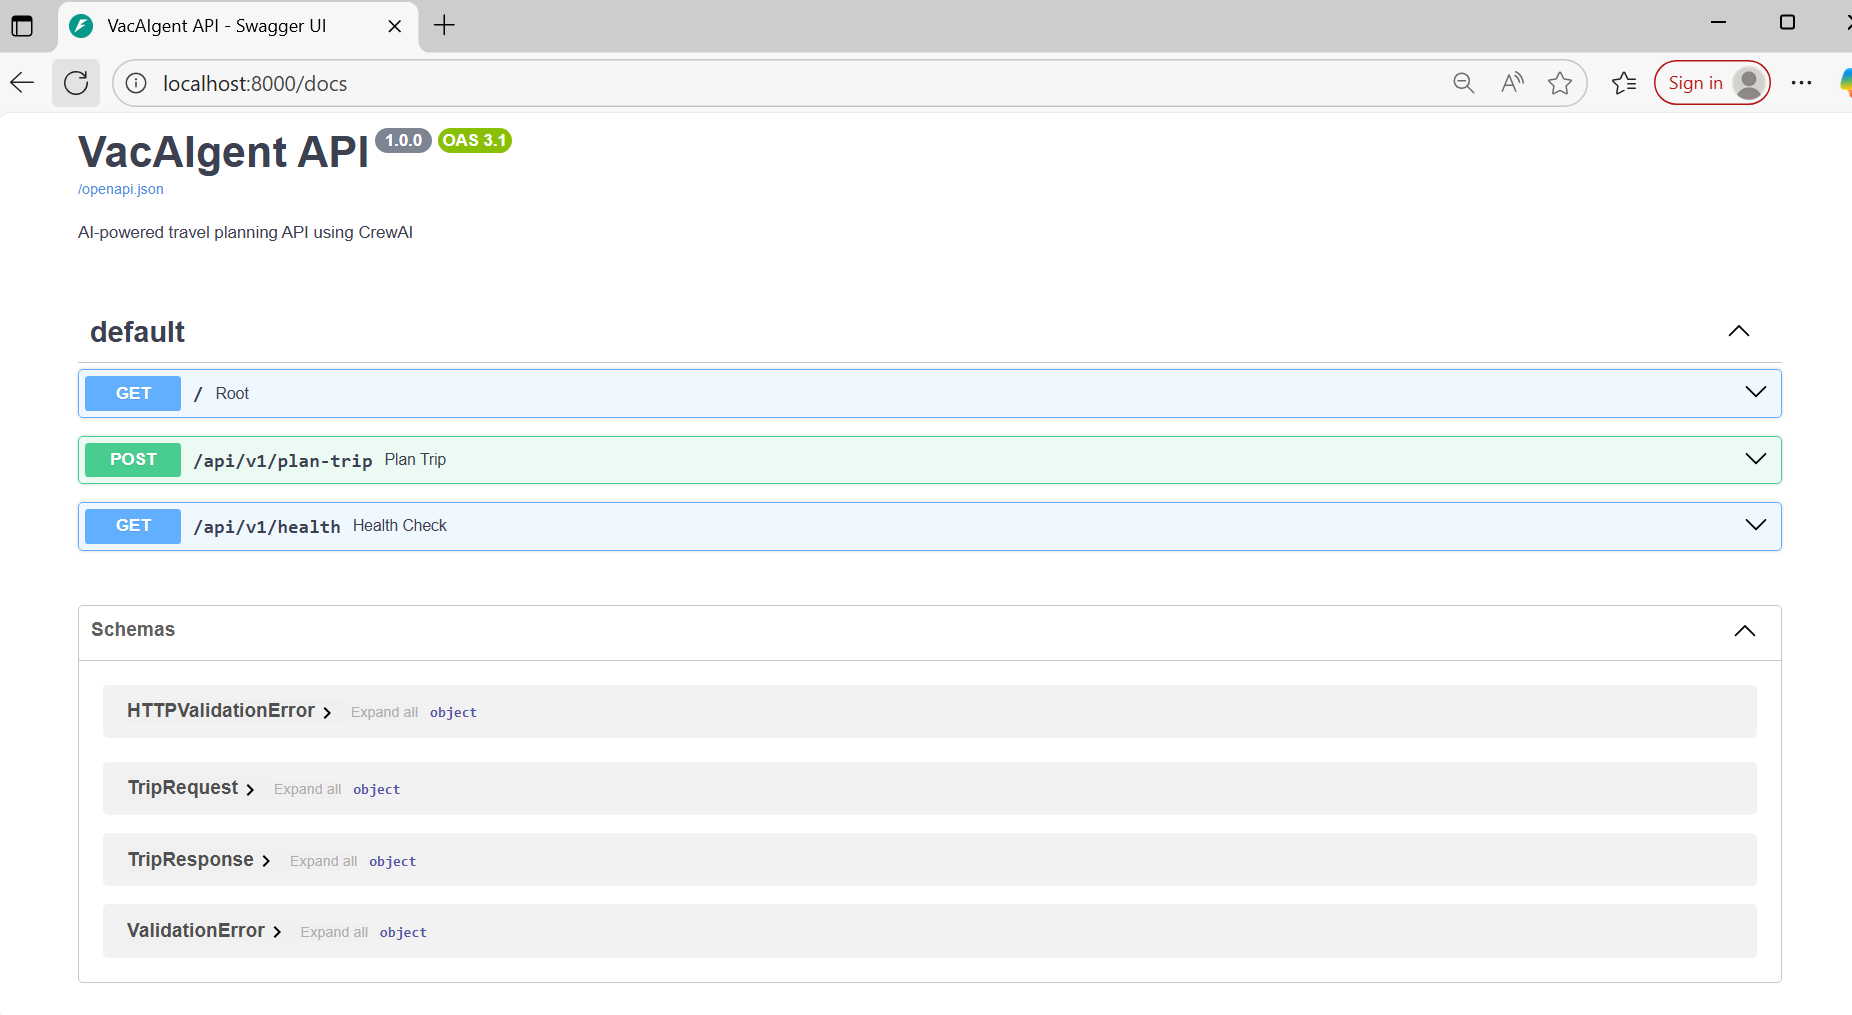 <br><br>
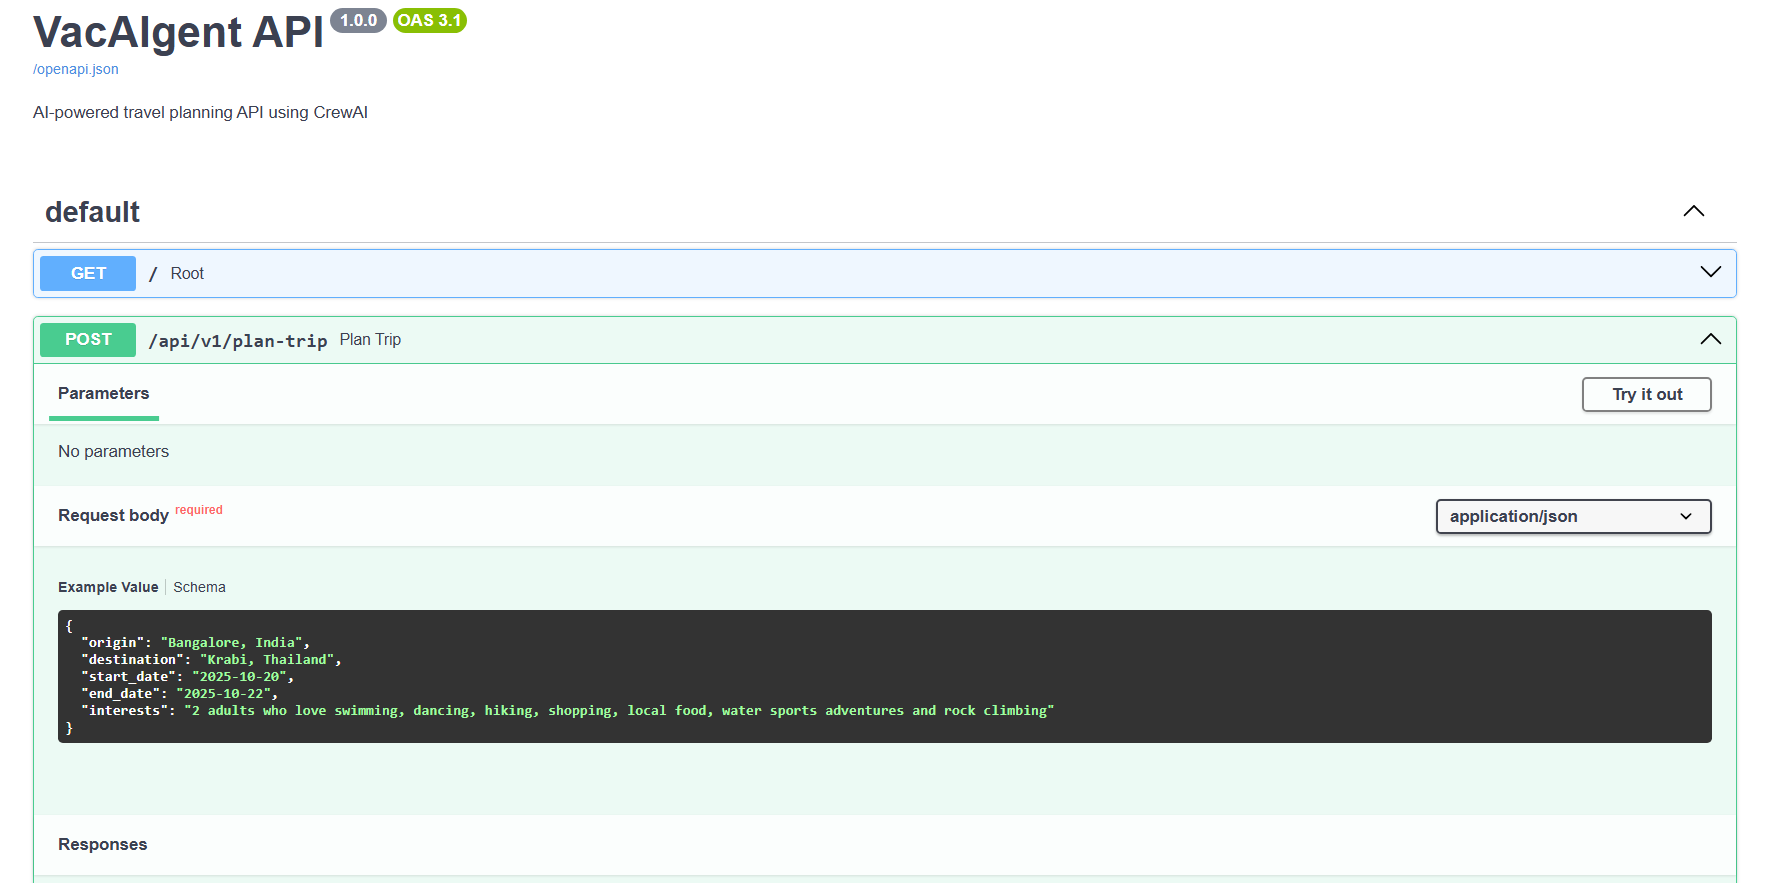 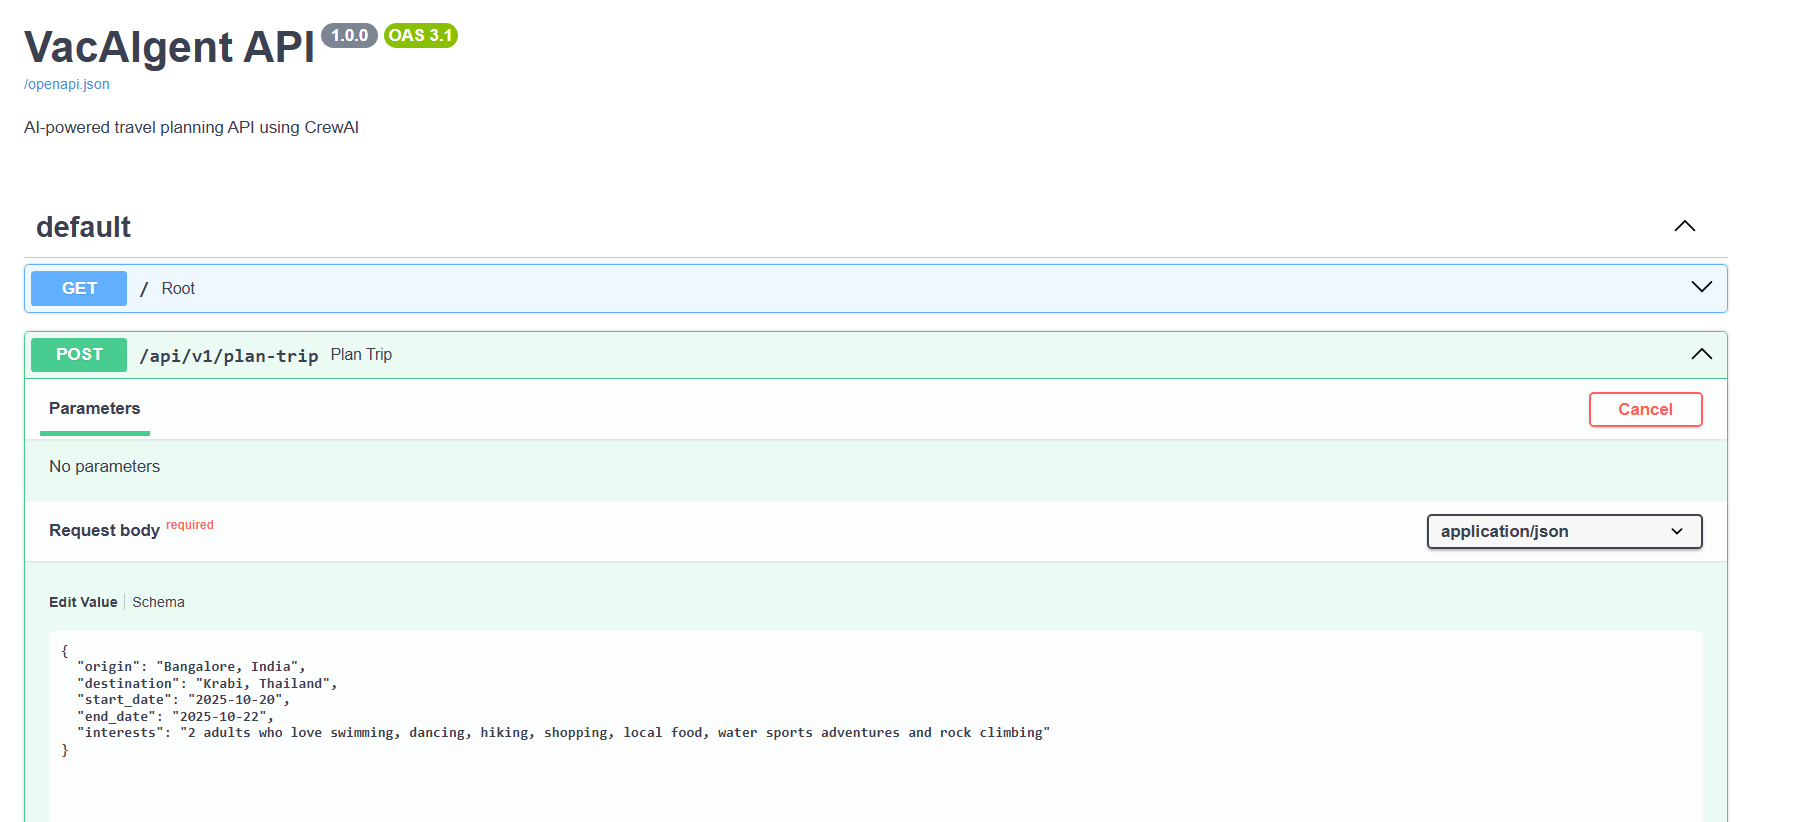 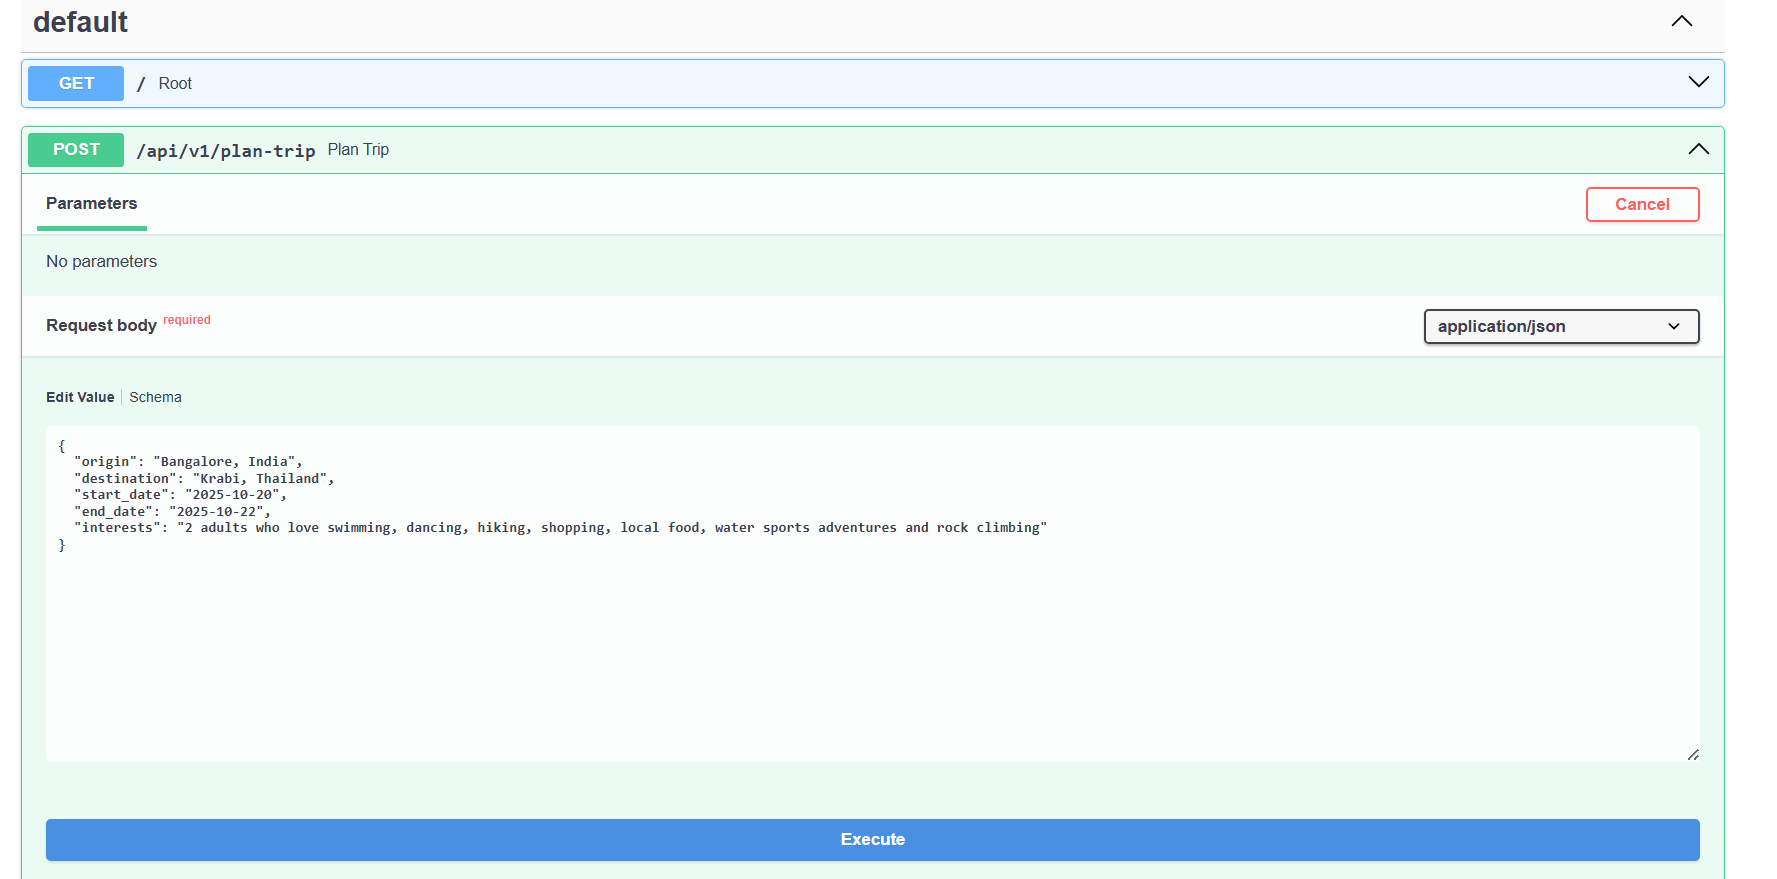 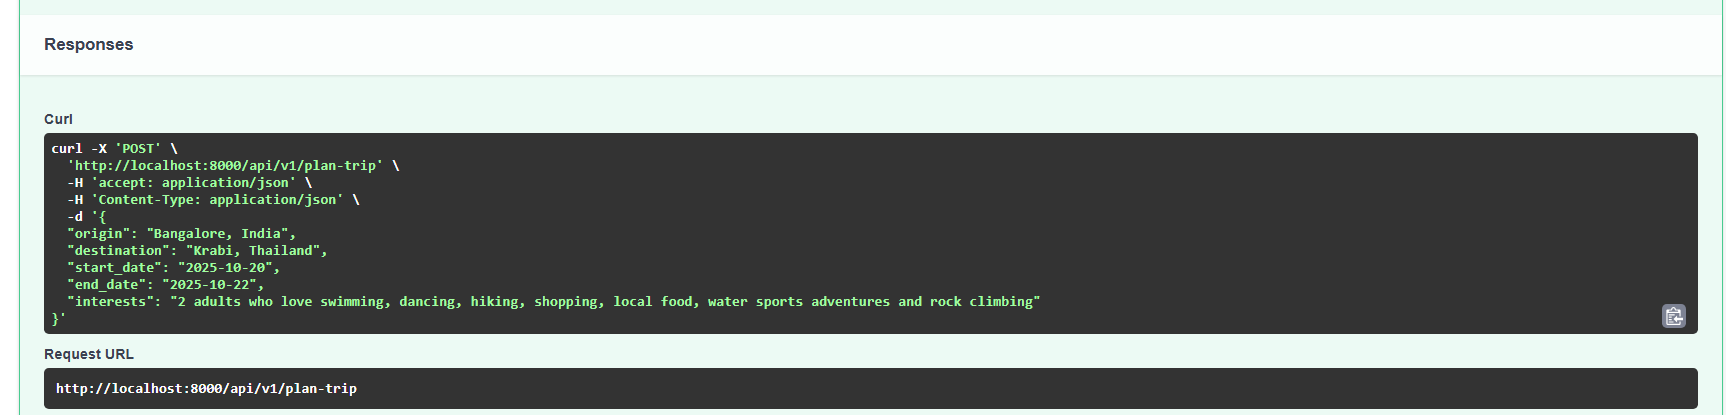
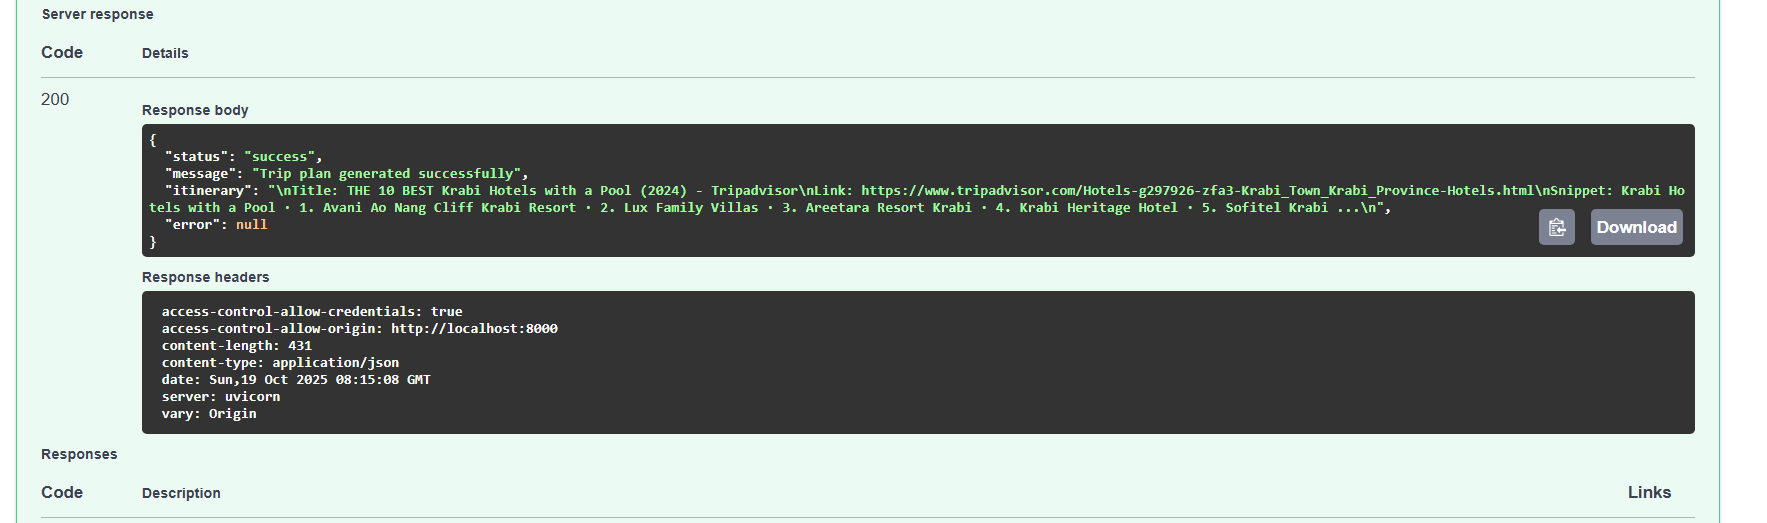 <br><br> 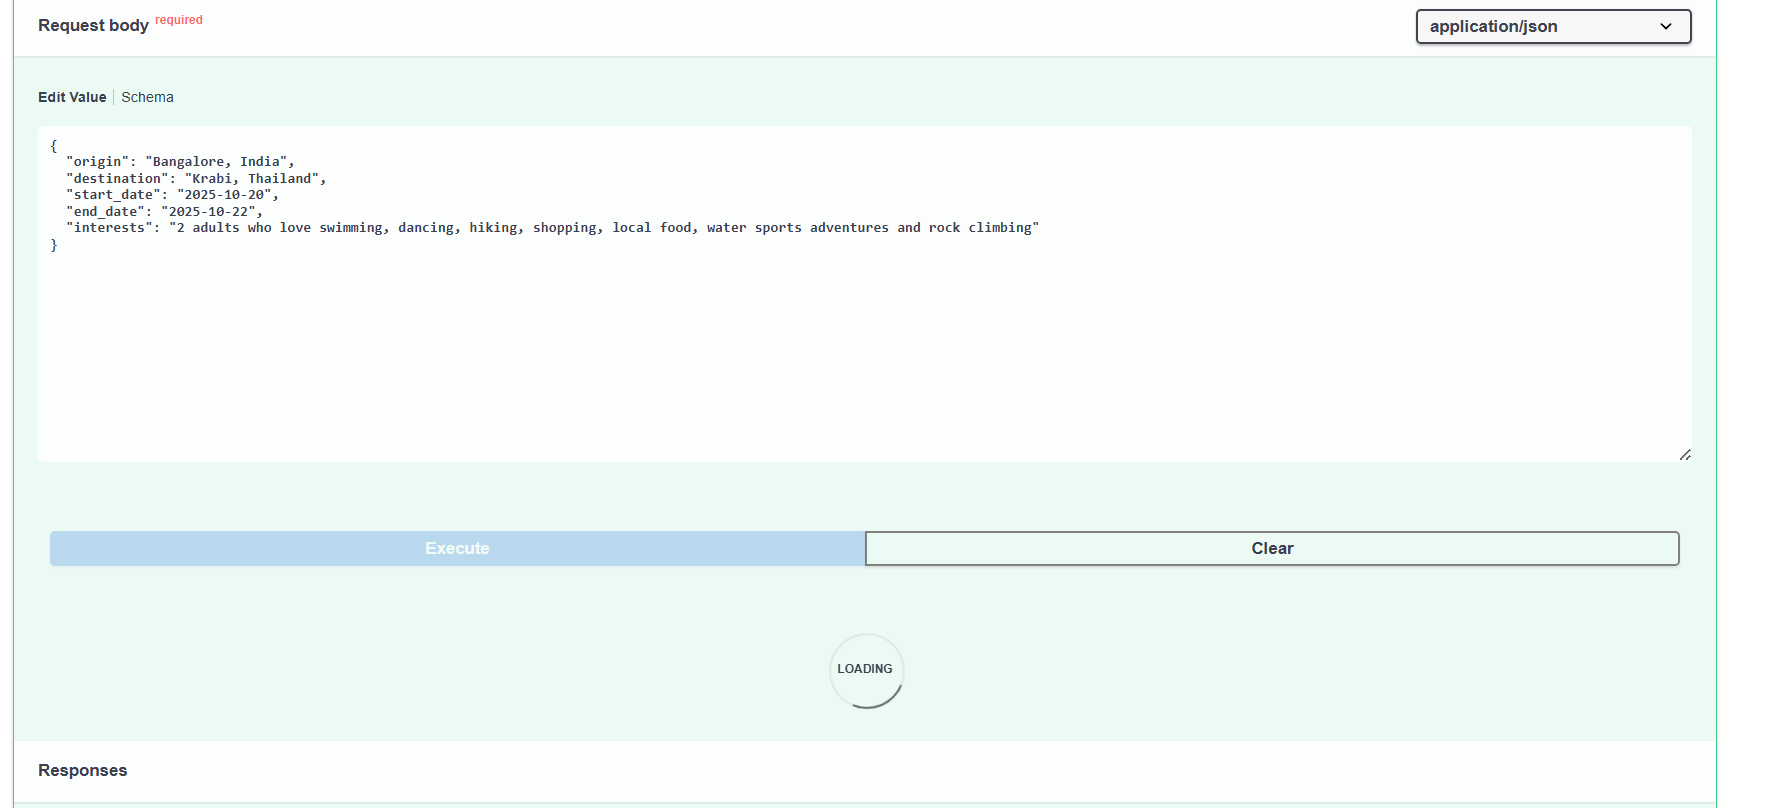 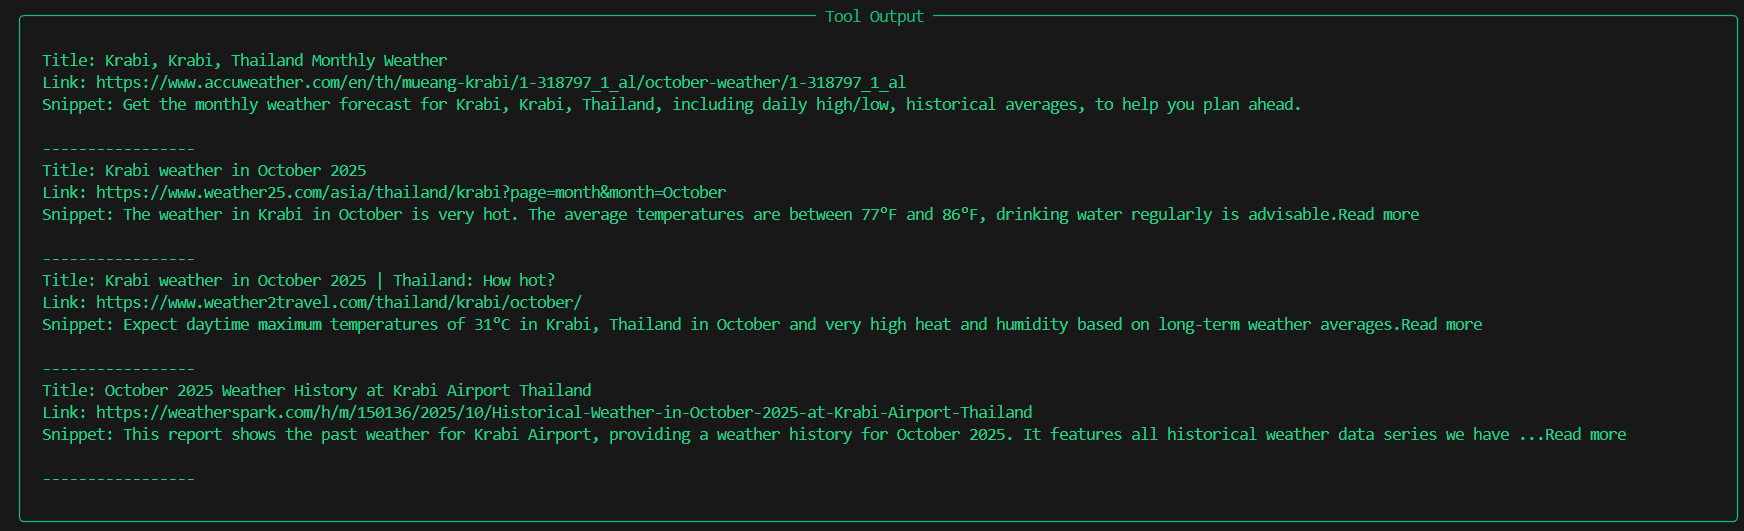 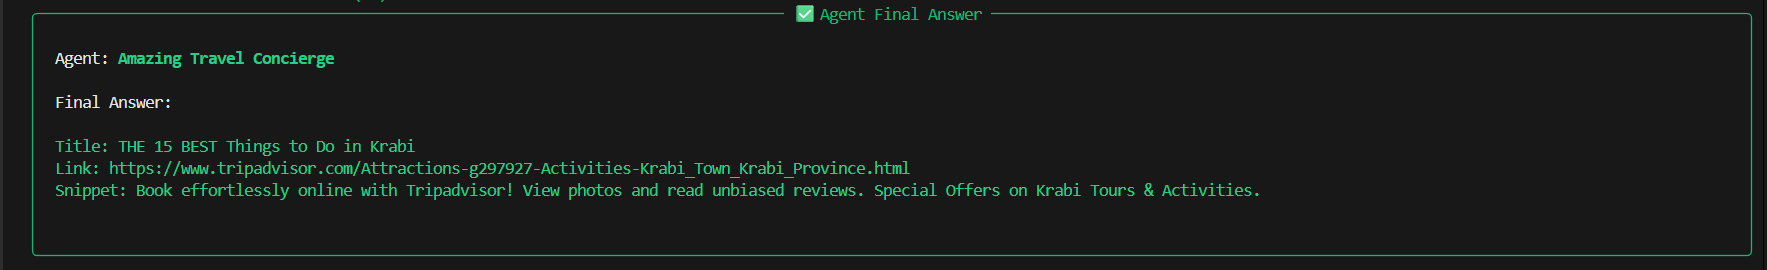 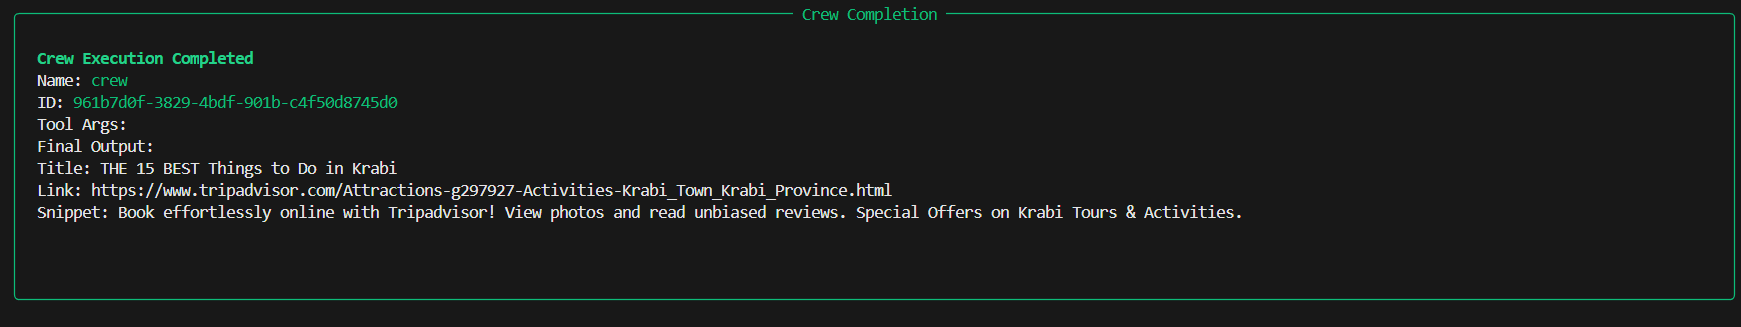

----

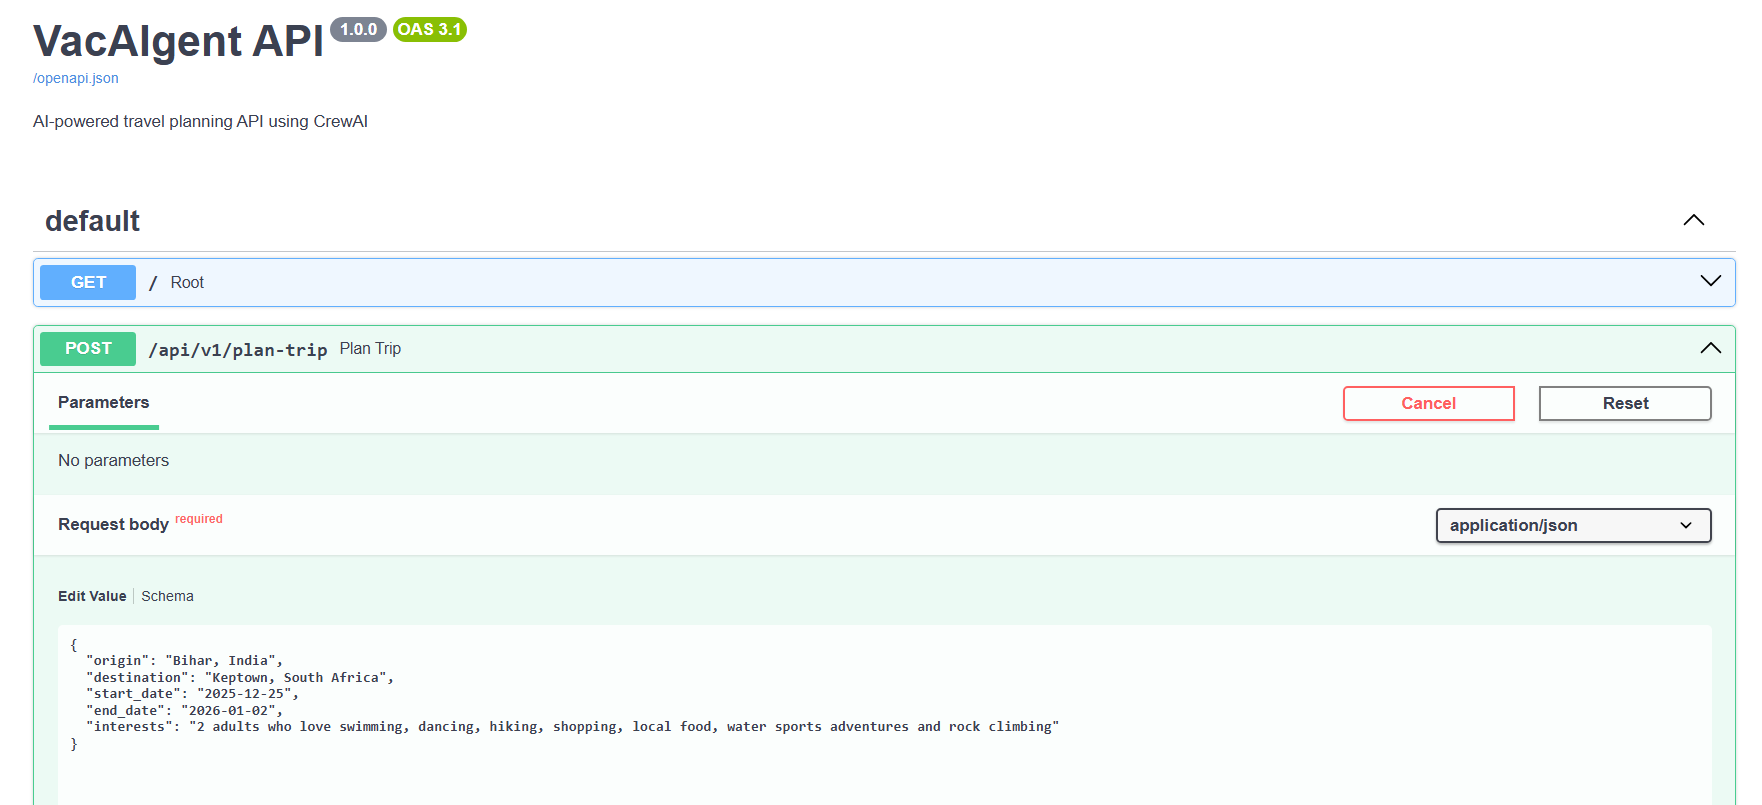 <br> 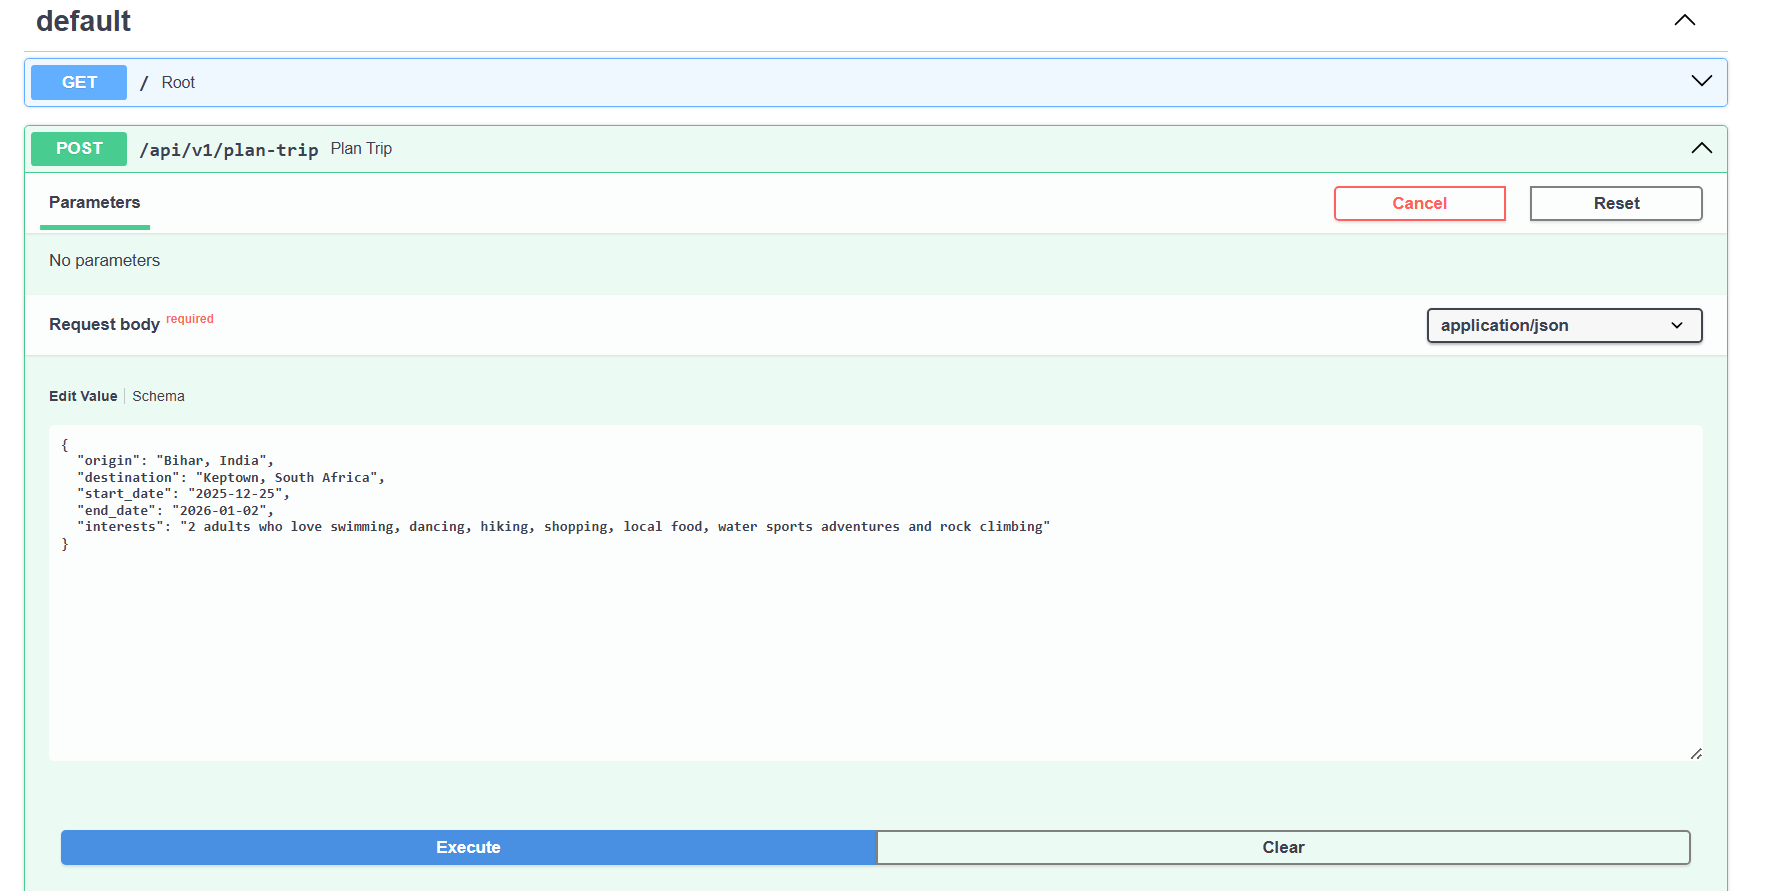 <br> 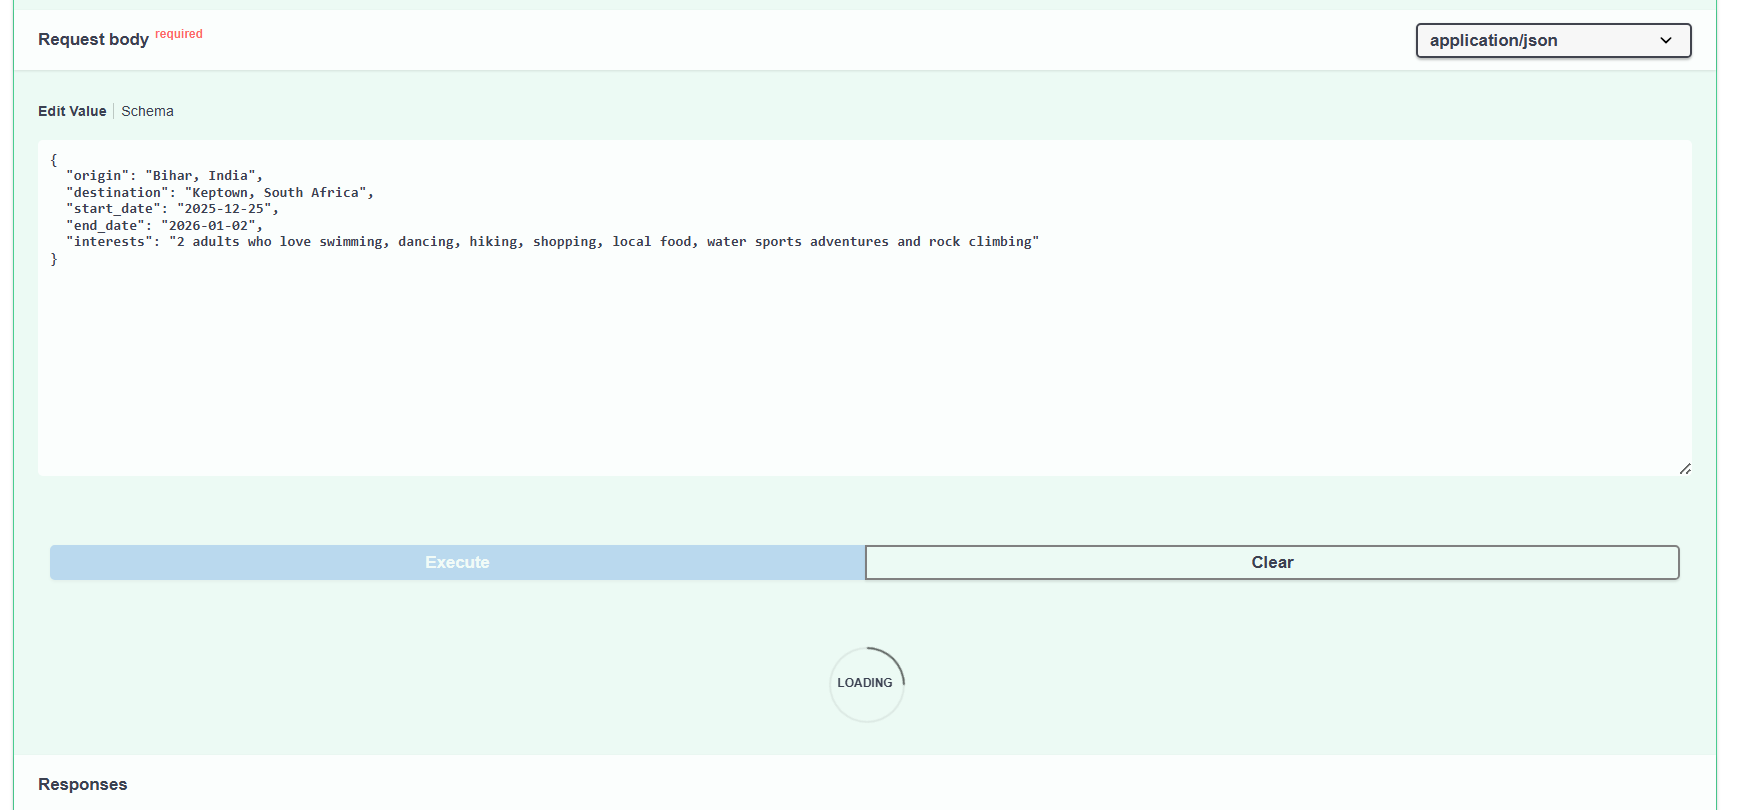 <br> 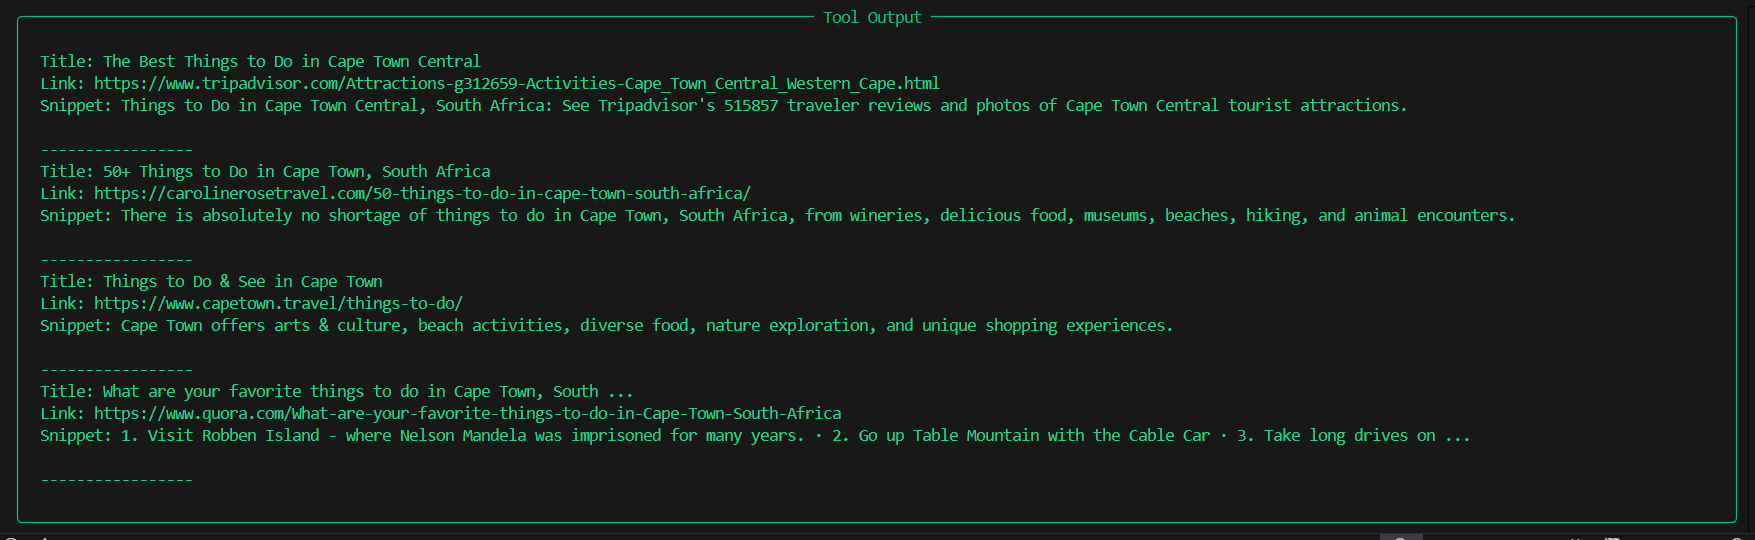
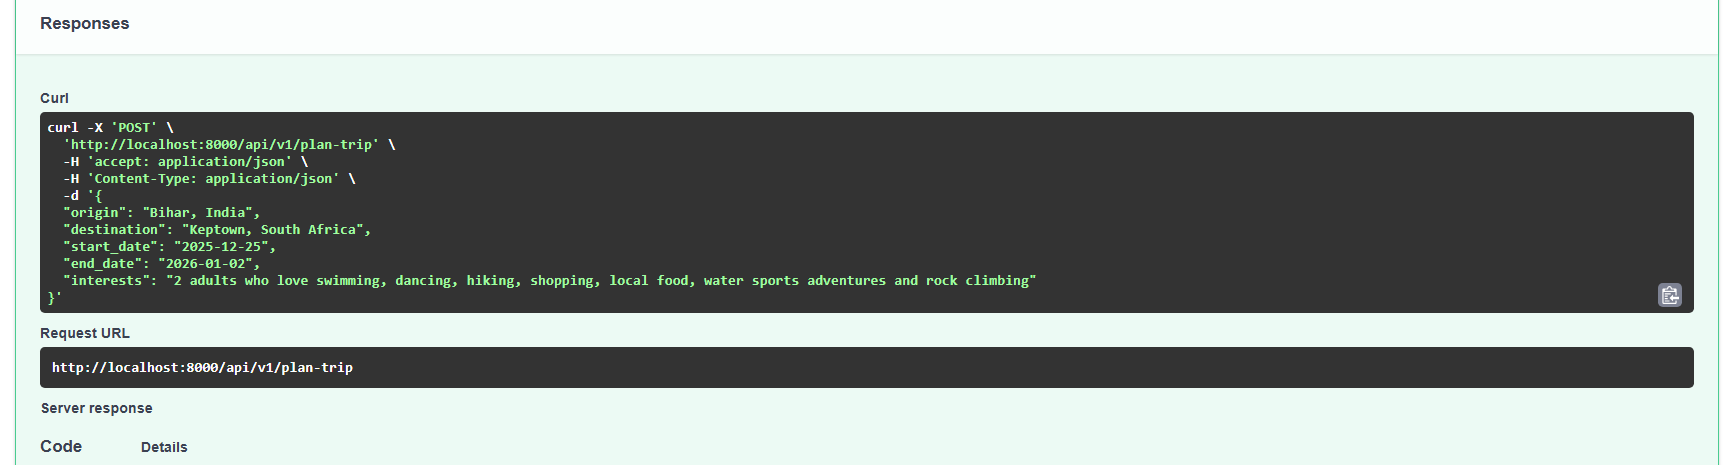 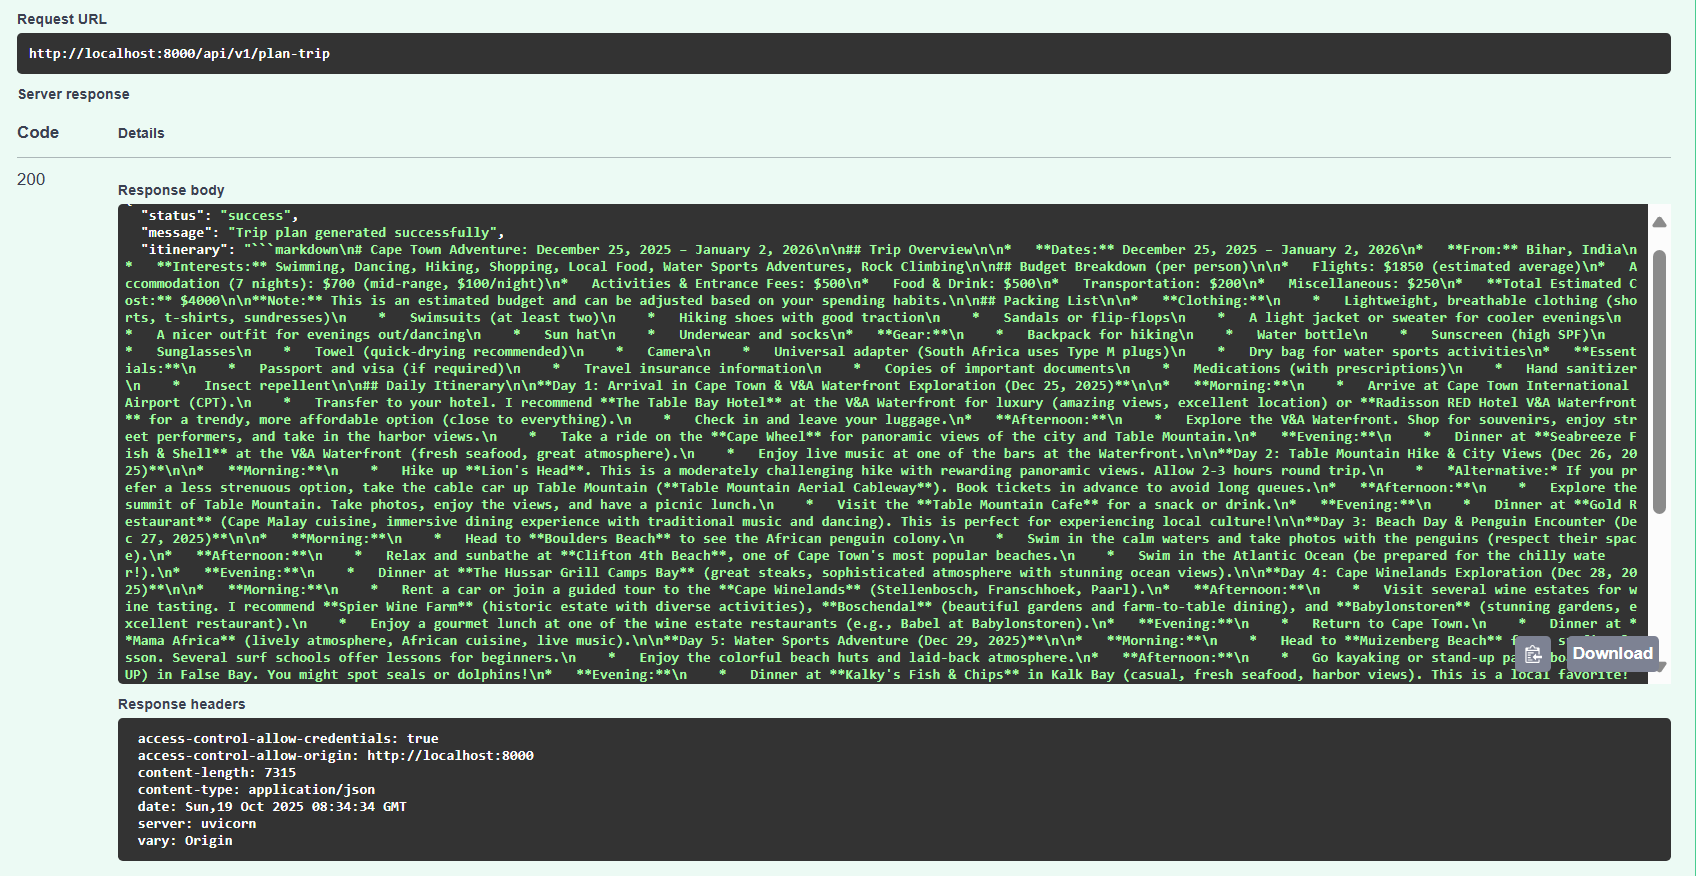 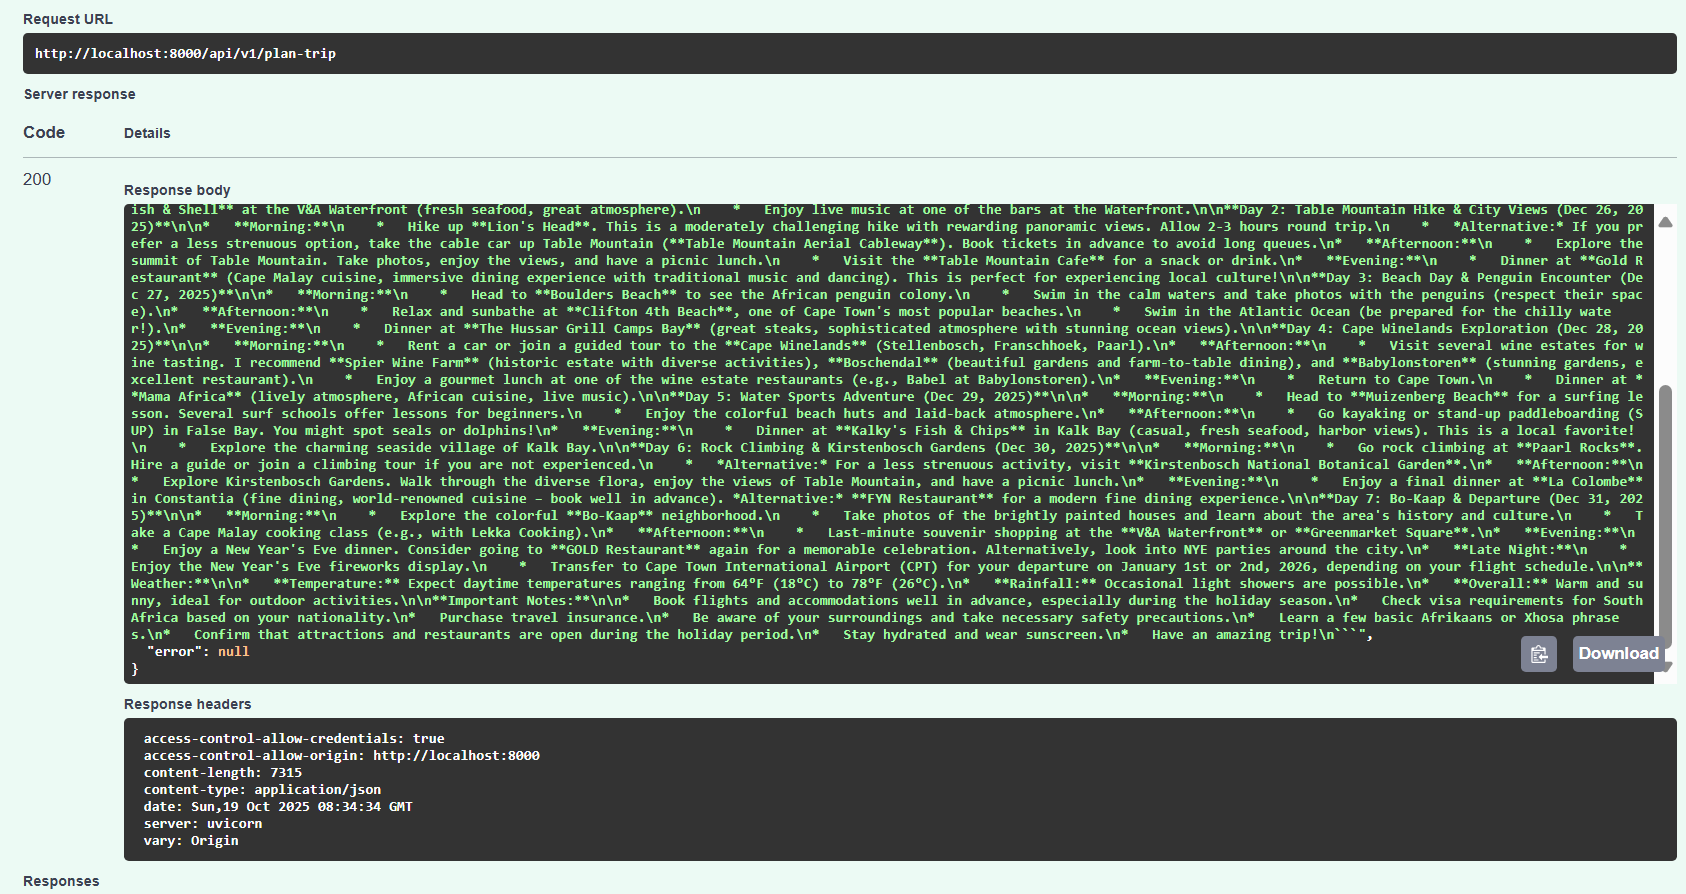 <br><br>

---

### FastAPI Response from Json file
```Json
{
  "status": "success",
  "message": "Trip plan generated successfully",
  "itinerary": "```markdown\n# Cape Town Adventure: December 25, 2025 – January 2, 2026\n\n## Trip Overview\n\n*   **Dates:** December 25, 2025 – January 2, 2026\n*   **From:** Bihar, India\n*   **Interests:** Swimming, Dancing, Hiking, Shopping, Local Food, Water Sports Adventures, Rock Climbing\n\n## Budget Breakdown (per person)\n\n*   Flights: $1850 (estimated average)\n*   Accommodation (7 nights): $700 (mid-range, $100/night)\n*   Activities & Entrance Fees: $500\n*   Food & Drink: $500\n*   Transportation: $200\n*   Miscellaneous: $250\n*   **Total Estimated Cost:** $4000\n\n**Note:** This is an estimated budget and can be adjusted based on your spending habits.\n\n## Packing List\n\n*   **Clothing:**\n    *   Lightweight, breathable clothing (shorts, t-shirts, sundresses)\n    *   Swimsuits (at least two)\n    *   Hiking shoes with good traction\n    *   Sandals or flip-flops\n    *   A light jacket or sweater for cooler evenings\n    *   A nicer outfit for evenings out/dancing\n    *   Sun hat\n    *   Underwear and socks\n*   **Gear:**\n    *   Backpack for hiking\n    *   Water bottle\n    *   Sunscreen (high SPF)\n    *   Sunglasses\n    *   Towel (quick-drying recommended)\n    *   Camera\n    *   Universal adapter (South Africa uses Type M plugs)\n    *   Dry bag for water sports activities\n*   **Essentials:**\n    *   Passport and visa (if required)\n    *   Travel insurance information\n    *   Copies of important documents\n    *   Medications (with prescriptions)\n    *   Hand sanitizer\n    *   Insect repellent\n\n## Daily Itinerary\n\n**Day 1: Arrival in Cape Town & V&A Waterfront Exploration (Dec 25, 2025)**\n\n*   **Morning:**\n    *   Arrive at Cape Town International Airport (CPT).\n    *   Transfer to your hotel. I recommend **The Table Bay Hotel** at the V&A Waterfront for luxury (amazing views, excellent location) or **Radisson RED Hotel V&A Waterfront** for a trendy, more affordable option (close to everything).\n    *   Check in and leave your luggage.\n*   **Afternoon:**\n    *   Explore the V&A Waterfront. Shop for souvenirs, enjoy street performers, and take in the harbor views.\n    *   Take a ride on the **Cape Wheel** for panoramic views of the city and Table Mountain.\n*   **Evening:**\n    *   Dinner at **Seabreeze Fish & Shell** at the V&A Waterfront (fresh seafood, great atmosphere).\n    *   Enjoy live music at one of the bars at the Waterfront.\n\n**Day 2: Table Mountain Hike & City Views (Dec 26, 2025)**\n\n*   **Morning:**\n    *   Hike up **Lion's Head**. This is a moderately challenging hike with rewarding panoramic views. Allow 2-3 hours round trip.\n    *   *Alternative:* If you prefer a less strenuous option, take the cable car up Table Mountain (**Table Mountain Aerial Cableway**). Book tickets in advance to avoid long queues.\n*   **Afternoon:**\n    *   Explore the summit of Table Mountain. Take photos, enjoy the views, and have a picnic lunch.\n    *   Visit the **Table Mountain Cafe** for a snack or drink.\n*   **Evening:**\n    *   Dinner at **Gold Restaurant** (Cape Malay cuisine, immersive dining experience with traditional music and dancing). This is perfect for experiencing local culture!\n\n**Day 3: Beach Day & Penguin Encounter (Dec 27, 2025)**\n\n*   **Morning:**\n    *   Head to **Boulders Beach** to see the African penguin colony.\n    *   Swim in the calm waters and take photos with the penguins (respect their space).\n*   **Afternoon:**\n    *   Relax and sunbathe at **Clifton 4th Beach**, one of Cape Town's most popular beaches.\n    *   Swim in the Atlantic Ocean (be prepared for the chilly water!).\n*   **Evening:**\n    *   Dinner at **The Hussar Grill Camps Bay** (great steaks, sophisticated atmosphere with stunning ocean views).\n\n**Day 4: Cape Winelands Exploration (Dec 28, 2025)**\n\n*   **Morning:**\n    *   Rent a car or join a guided tour to the **Cape Winelands** (Stellenbosch, Franschhoek, Paarl).\n*   **Afternoon:**\n    *   Visit several wine estates for wine tasting. I recommend **Spier Wine Farm** (historic estate with diverse activities), **Boschendal** (beautiful gardens and farm-to-table dining), and **Babylonstoren** (stunning gardens, excellent restaurant).\n    *   Enjoy a gourmet lunch at one of the wine estate restaurants (e.g., Babel at Babylonstoren).\n*   **Evening:**\n    *   Return to Cape Town.\n    *   Dinner at **Mama Africa** (lively atmosphere, African cuisine, live music).\n\n**Day 5: Water Sports Adventure (Dec 29, 2025)**\n\n*   **Morning:**\n    *   Head to **Muizenberg Beach** for a surfing lesson. Several surf schools offer lessons for beginners.\n    *   Enjoy the colorful beach huts and laid-back atmosphere.\n*   **Afternoon:**\n    *   Go kayaking or stand-up paddleboarding (SUP) in False Bay. You might spot seals or dolphins!\n*   **Evening:**\n    *   Dinner at **Kalky's Fish & Chips** in Kalk Bay (casual, fresh seafood, harbor views). This is a local favorite!\n    *   Explore the charming seaside village of Kalk Bay.\n\n**Day 6: Rock Climbing & Kirstenbosch Gardens (Dec 30, 2025)**\n\n*   **Morning:**\n    *   Go rock climbing at **Paarl Rocks**. Hire a guide or join a climbing tour if you are not experienced.\n    *   *Alternative:* For a less strenuous activity, visit **Kirstenbosch National Botanical Garden**.\n*   **Afternoon:**\n    *   Explore Kirstenbosch Gardens. Walk through the diverse flora, enjoy the views of Table Mountain, and have a picnic lunch.\n*   **Evening:**\n    *   Enjoy a final dinner at **La Colombe** in Constantia (fine dining, world-renowned cuisine – book well in advance). *Alternative:* **FYN Restaurant** for a modern fine dining experience.\n\n**Day 7: Bo-Kaap & Departure (Dec 31, 2025)**\n\n*   **Morning:**\n    *   Explore the colorful **Bo-Kaap** neighborhood.\n    *   Take photos of the brightly painted houses and learn about the area's history and culture.\n    *   Take a Cape Malay cooking class (e.g., with Lekka Cooking).\n*   **Afternoon:**\n    *   Last-minute souvenir shopping at the **V&A Waterfront** or **Greenmarket Square**.\n*   **Evening:**\n    *   Enjoy a New Year's Eve dinner. Consider going to **GOLD Restaurant** again for a memorable celebration. Alternatively, look into NYE parties around the city.\n*   **Late Night:**\n    *   Enjoy the New Year's Eve fireworks display.\n    *   Transfer to Cape Town International Airport (CPT) for your departure on January 1st or 2nd, 2026, depending on your flight schedule.\n\n**Weather:**\n\n*   **Temperature:** Expect daytime temperatures ranging from 64°F (18°C) to 78°F (26°C).\n*   **Rainfall:** Occasional light showers are possible.\n*   **Overall:** Warm and sunny, ideal for outdoor activities.\n\n**Important Notes:**\n\n*   Book flights and accommodations well in advance, especially during the holiday season.\n*   Check visa requirements for South Africa based on your nationality.\n*   Purchase travel insurance.\n*   Be aware of your surroundings and take necessary safety precautions.\n*   Learn a few basic Afrikaans or Xhosa phrases.\n*   Confirm that attractions and restaurants are open during the holiday period.\n*   Stay hydrated and wear sunscreen.\n*   Have an amazing trip!\n```",
  "error": null
}
```

---

### Readable format of above json file using ChatGpt
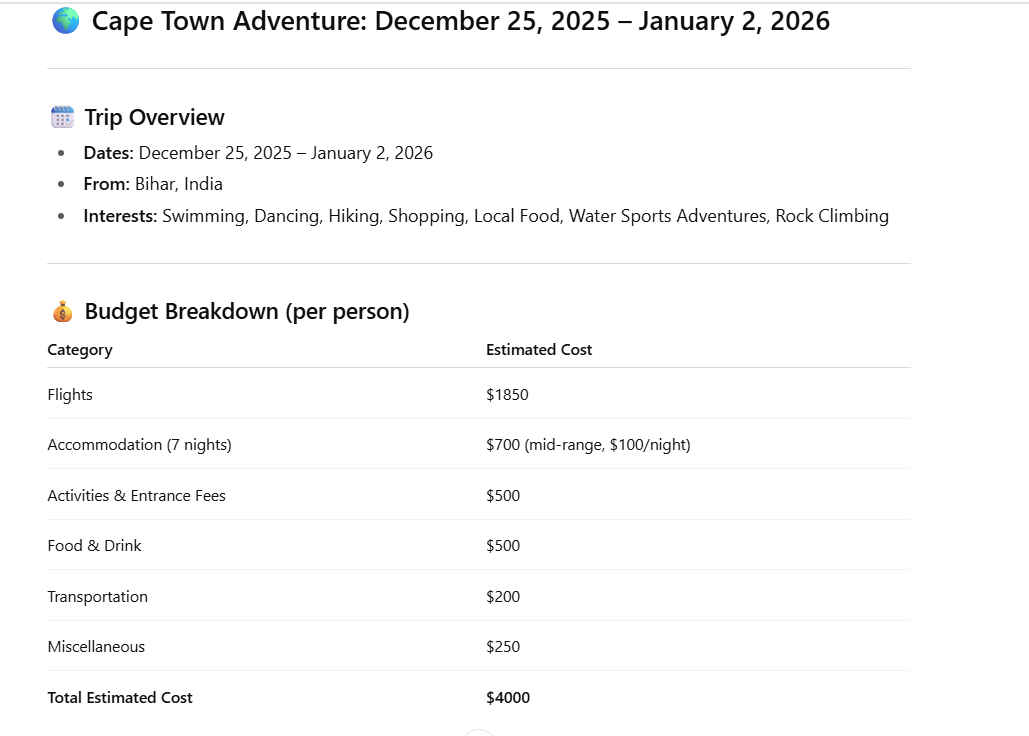 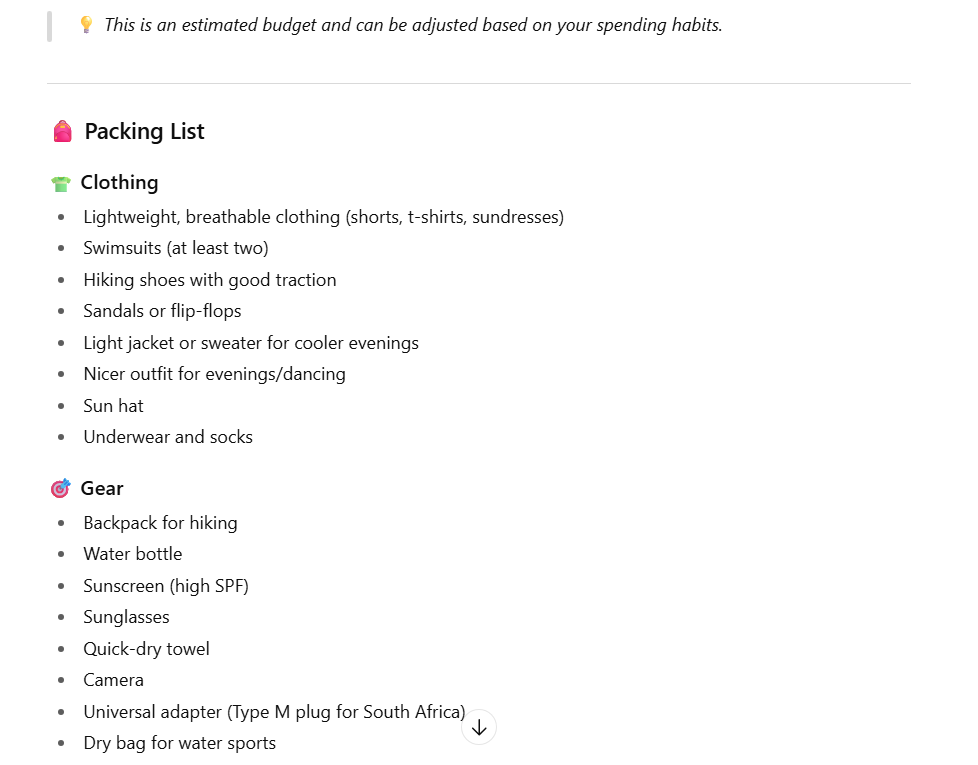 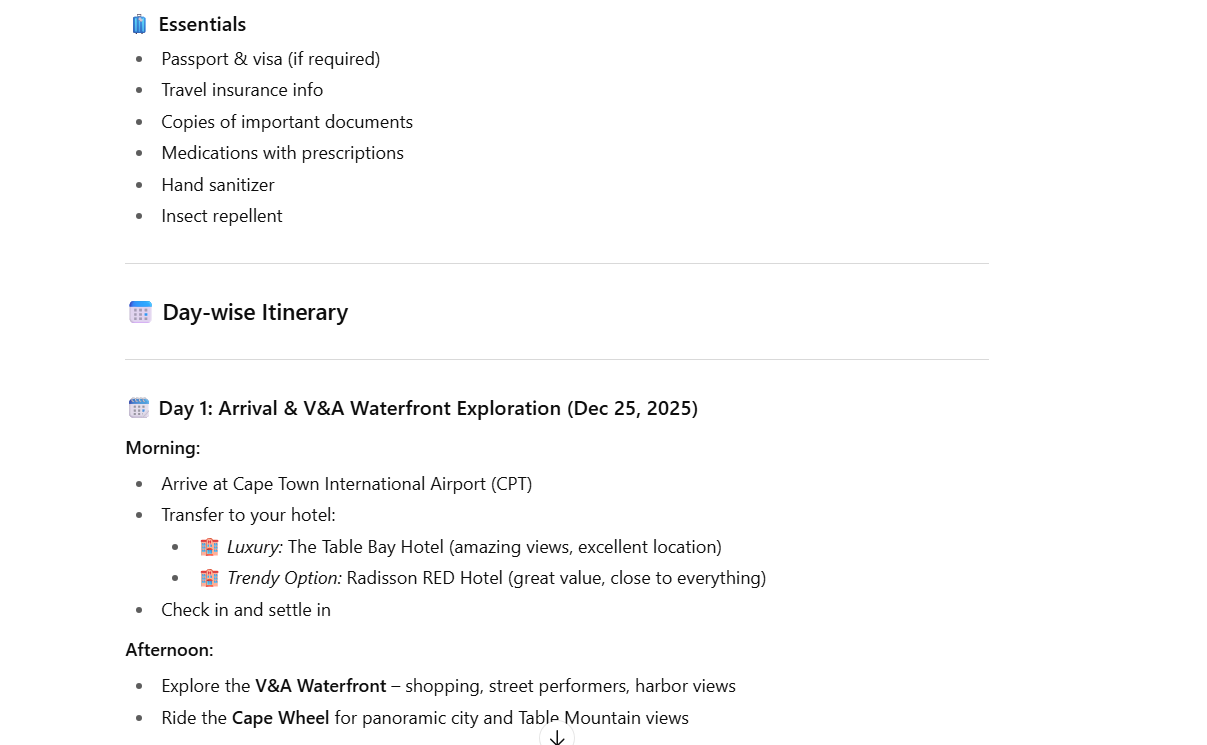 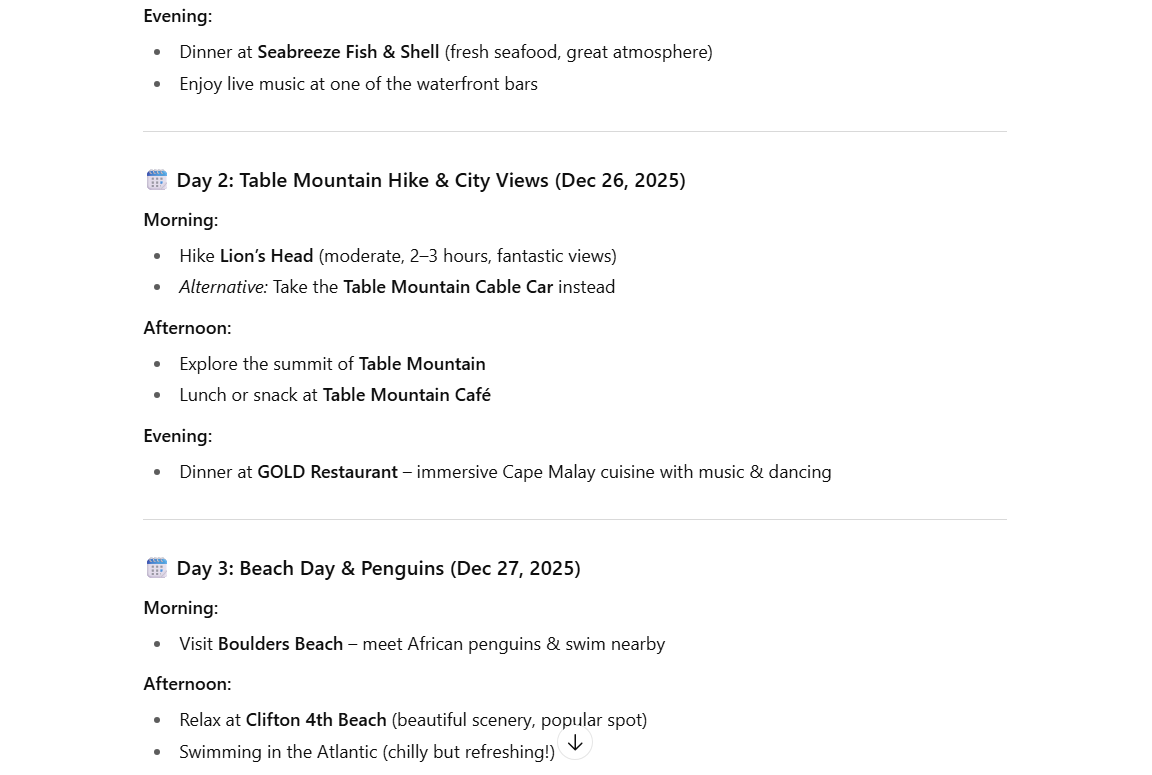 
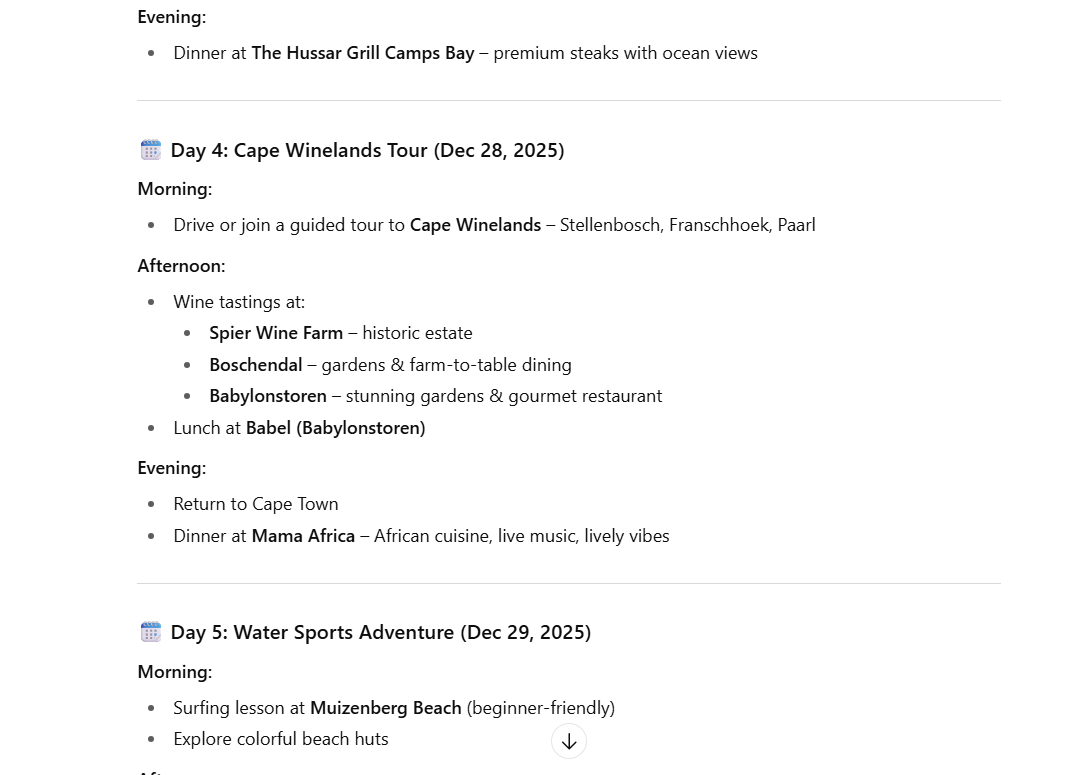 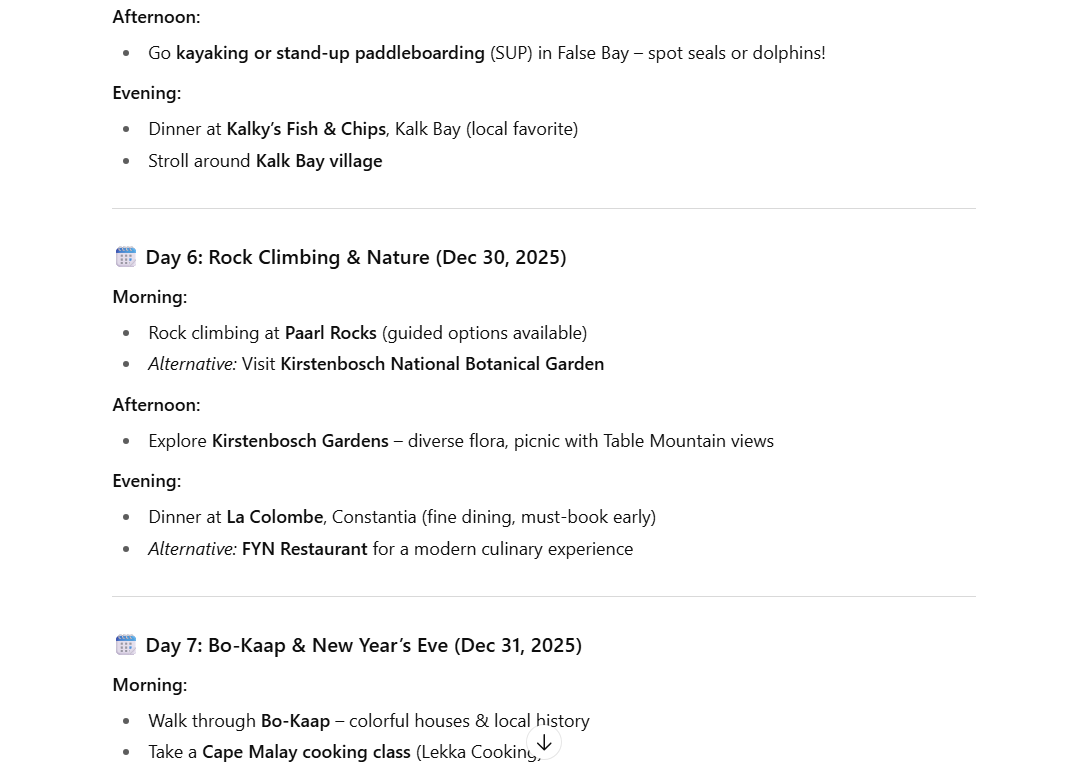 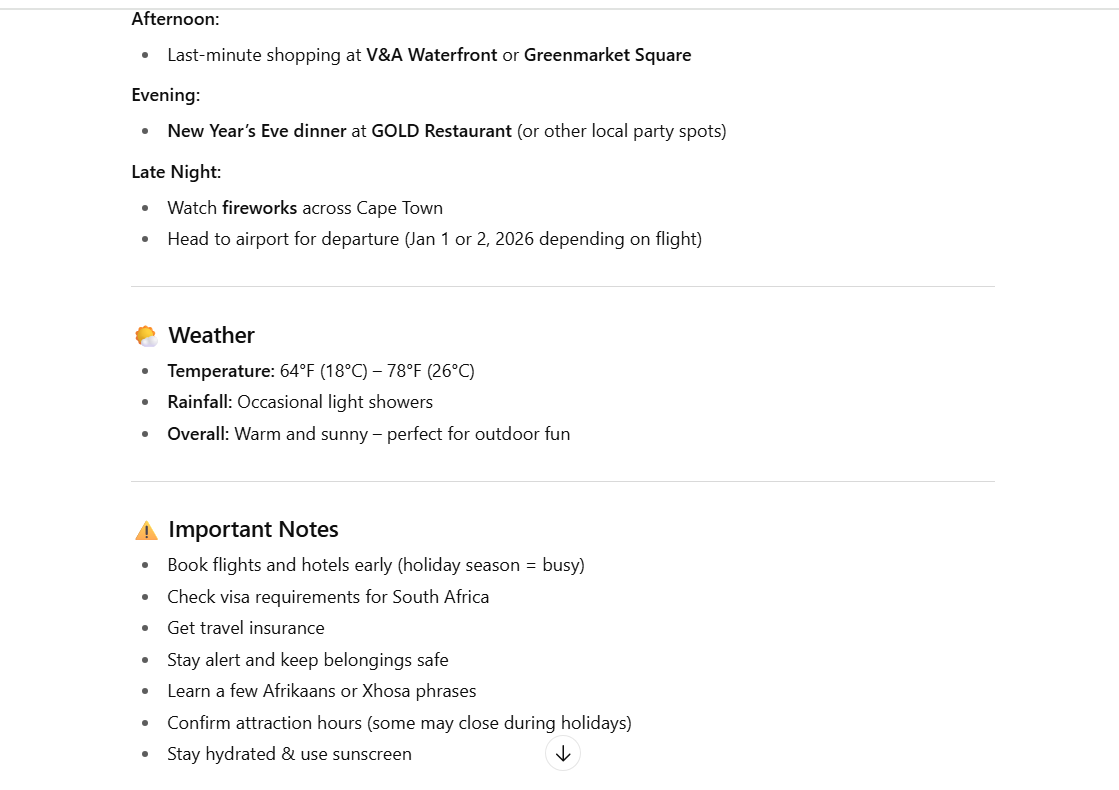 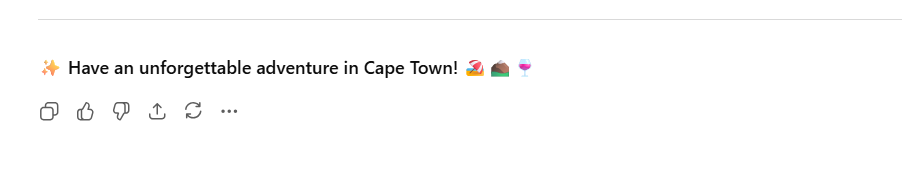

---